# Challenge 1 — Titanic

## **Import thư viện**

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')


## **I. Phân tích khám phá dữ liệu**

### **1. Đọc dữ liệu và khám phá tổng quan**

In [80]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")


In [81]:
print(train.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [82]:
print("Dữ liệu số")
display(train.describe())


Dữ liệu số


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [83]:
print("Dữ liệu object")
train.describe(include=['object'])


Dữ liệu object


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


Sex và Embarked có 2-3 dữ liệu độc nhất -> có thể dùng để huấn luyện mô hình

In [84]:
display(train.head())
display(test.head())


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


,feature,missing_count,missing_percent
0,Cabin,687,77.10
1,Age,177,19.87
2,Embarked,2,0.22


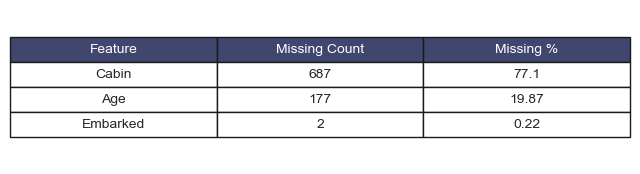

In [85]:
# Bảng thống kê giá trị thiếu
missing_counts = train.isnull().sum()
missing_percent = (missing_counts / len(train) * 100).round(2)
missing_df = pd.DataFrame({
    'feature': missing_counts.index,
    'missing_count': missing_counts.values,
    'missing_percent': missing_percent.values
})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_percent', ascending=False)

if missing_df.empty:
    print("Không có giá trị thiếu trong dữ liệu.")
else:

    # Hiển thị dataframe
    display(missing_df.reset_index(drop=True))

    # Vẽ bảng matplotlib từ dataframe
    fig, ax = plt.subplots(figsize=(8, max(2, 0.5 * len(missing_df))))
    ax.axis('off')
    table_data = missing_df.reset_index(drop=True).values
    col_labels = ['Feature', 'Missing Count', 'Missing %']
    table = ax.table(cellText=table_data, colLabels=col_labels, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    # tô nền header
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#40466e')
            cell._text.set_color('white')
    plt.show()


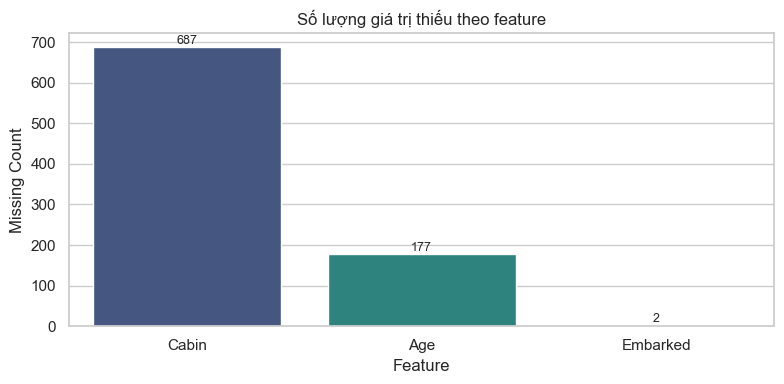

In [86]:
# Biểu đồ đơn giản hơn bằng seaborn
missing_counts = train.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

if missing_counts.empty:
    print("Không có giá trị thiếu trong dữ liệu.")
else:
    ms = missing_counts.reset_index()
    ms.columns = ['feature', 'missing_count']
    plt.figure(figsize=(8,4))
    ax = sns.barplot(x='feature', y='missing_count', data=ms, palette='viridis')
    ax.set_title('Số lượng giá trị thiếu theo feature')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Missing Count')
    plt.xticks(rotation=0, ha='center')

    # Ghi nhãn số lượng lên từng cột
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


Tỷ lệ sống sót trong tập huấn luyện:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


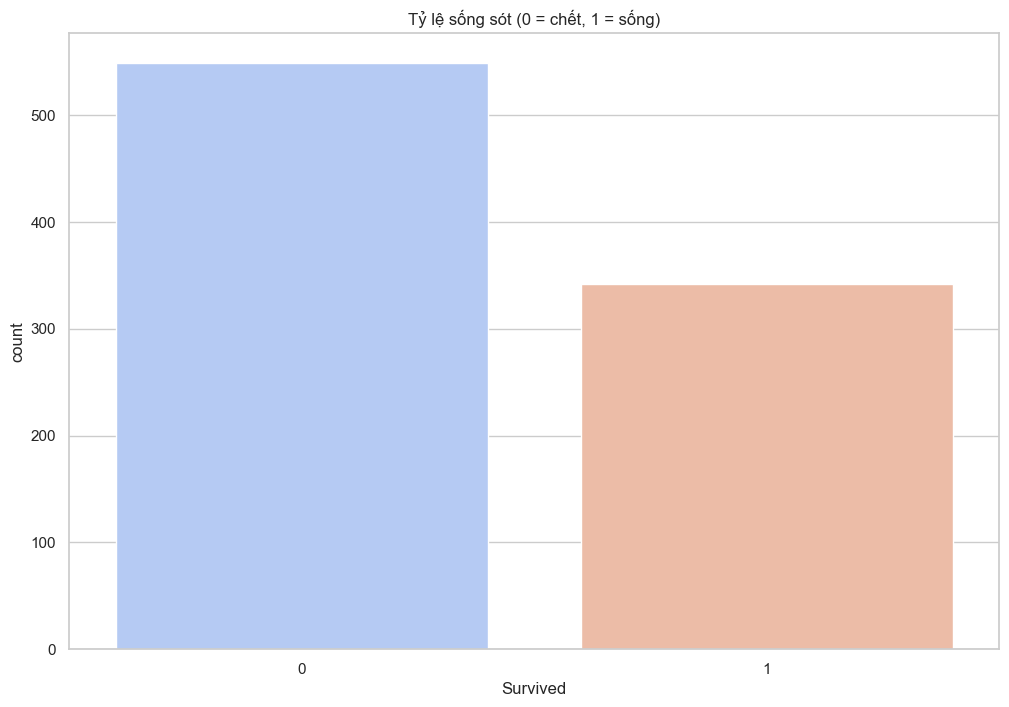

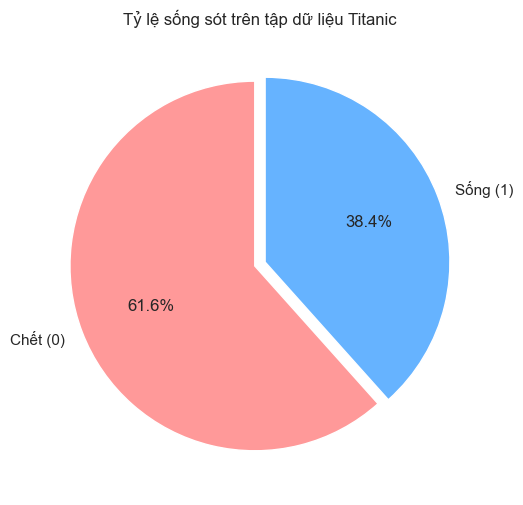

In [87]:
print("Tỷ lệ sống sót trong tập huấn luyện:")
print(train['Survived'].value_counts(normalize=True))

sns.countplot(x='Survived', data=train, palette='coolwarm')
plt.title("Tỷ lệ sống sót (0 = chết, 1 = sống)")
plt.show()

counts = train['Survived'].value_counts().sort_index()
labels = ['Chết (0)', 'Sống (1)']
colors = ['#ff9999', '#66b3ff']
plt.figure(figsize=(6,6))
counts.plot.pie(labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=(0.03,0.03), shadow=False)
plt.ylabel('')
plt.title('Tỷ lệ sống sót trên tập dữ liệu Titanic')
plt.show()


### **2. Phân tích khám phá dữ liệu**

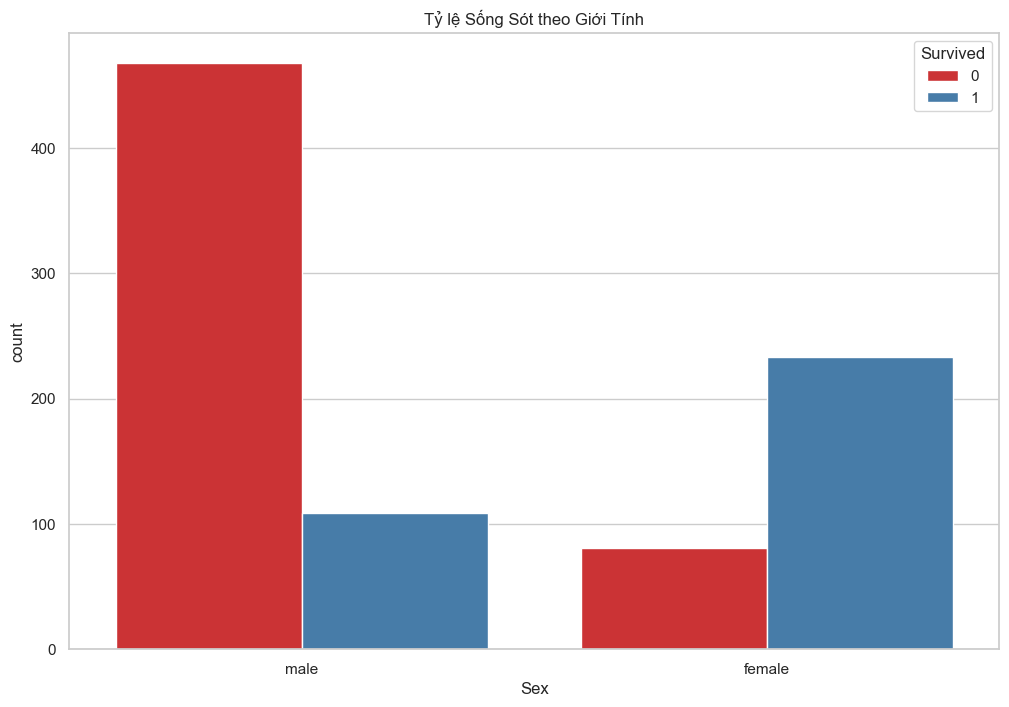

In [88]:
sns.countplot(x='Sex', hue='Survived', data=train, palette='Set1')
plt.title('Tỷ lệ Sống Sót theo Giới Tính')
plt.show()


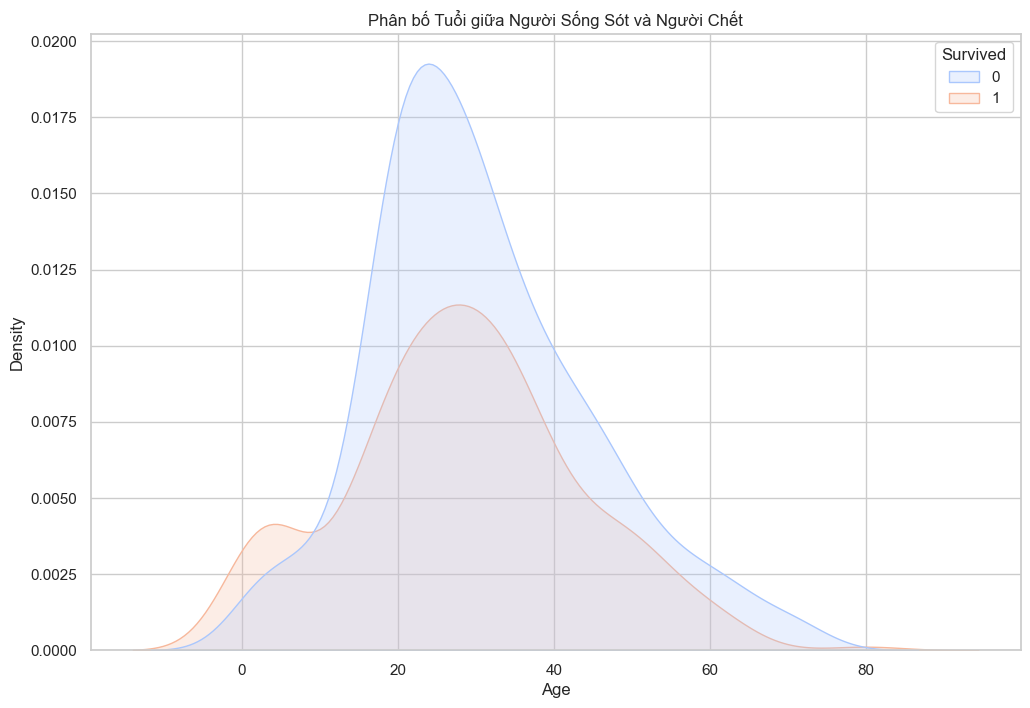

In [89]:
sns.kdeplot(data=train, x='Age', hue='Survived', fill=True, palette='coolwarm')
plt.title('Phân bố Tuổi giữa Người Sống Sót và Người Chết')
plt.show()


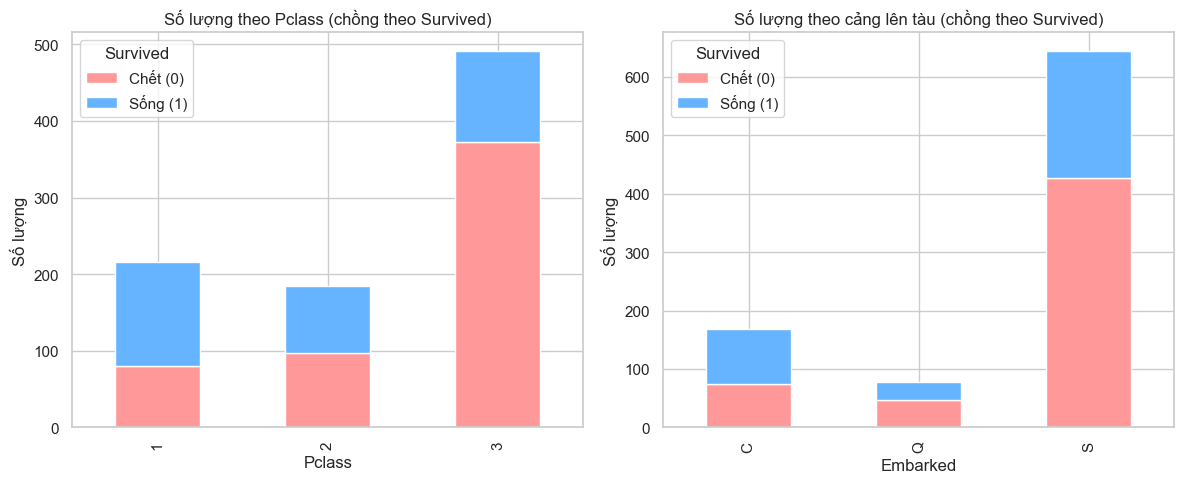

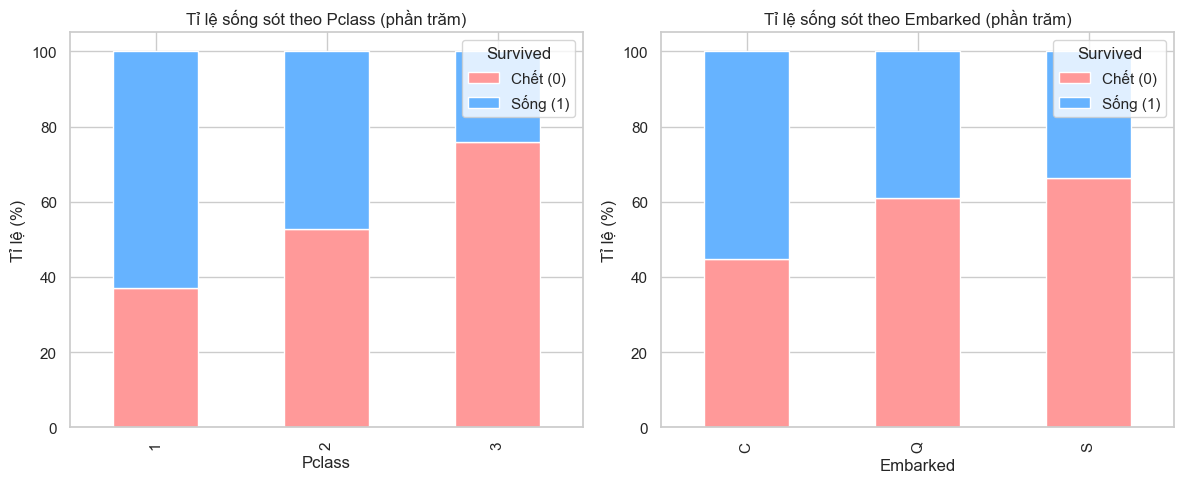

In [90]:
# Biểu đồ cột chồng (counts) cho Pclass và Embarked
counts_pclass = train.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)

# Định nghĩa thứ tự cho các cảng (emb_order). Nếu muốn cố định thứ tự phổ biến: ['C','Q','S']
# Nếu một trong các giá trị không có trong dữ liệu thì sẽ bị loại bỏ.
preferred_order = ['C', 'Q', 'S']
available_emb = train['Embarked'].dropna().unique().tolist()
emb_order = [e for e in preferred_order if e in available_emb]
if not emb_order:
	# fallback: dùng thứ tự xuất hiện trong dữ liệu (hoặc sắp xếp nếu cần)
	emb_order = sorted(available_emb)

# Tạo counts cho Embarked theo thứ tự emb_order và điền 0 cho các ô thiếu
counts_emb = (
	train[train['Embarked'].notna()]
	.groupby(['Embarked', 'Survived'])
	.size()
	.unstack(fill_value=0)
	.reindex(emb_order)
	.fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Pclass
counts_pclass.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=axes[0])
axes[0].set_xlabel('Pclass')
axes[0].set_ylabel('Số lượng')
axes[0].set_title('Số lượng theo Pclass (chồng theo Survived)')
axes[0].legend(['Chết (0)', 'Sống (1)'], title='Survived')

# Embarked (theo thứ tự emb_order)
counts_emb.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=axes[1])
axes[1].set_xlabel('Embarked')
axes[1].set_ylabel('Số lượng')
axes[1].set_title('Số lượng theo cảng lên tàu (chồng theo Survived)')
axes[1].legend(['Chết (0)', 'Sống (1)'], title='Survived')

plt.tight_layout()
plt.show()

# Nếu muốn biểu diễn theo phần trăm thay vì counts:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
pct_pclass = counts_pclass.div(counts_pclass.sum(axis=1), axis=0) * 100
pct_emb = counts_emb.div(counts_emb.sum(axis=1), axis=0) * 100

pct_pclass.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=axes[0])
axes[0].set_ylabel('Tỉ lệ (%)')
axes[0].set_title('Tỉ lệ sống sót theo Pclass (phần trăm)')
axes[0].legend(['Chết (0)', 'Sống (1)'], title='Survived')

pct_emb.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=axes[1])
axes[1].set_ylabel('Tỉ lệ (%)')
axes[1].set_title('Tỉ lệ sống sót theo Embarked (phần trăm)')
axes[1].legend(['Chết (0)', 'Sống (1)'], title='Survived')

plt.tight_layout()
plt.show()


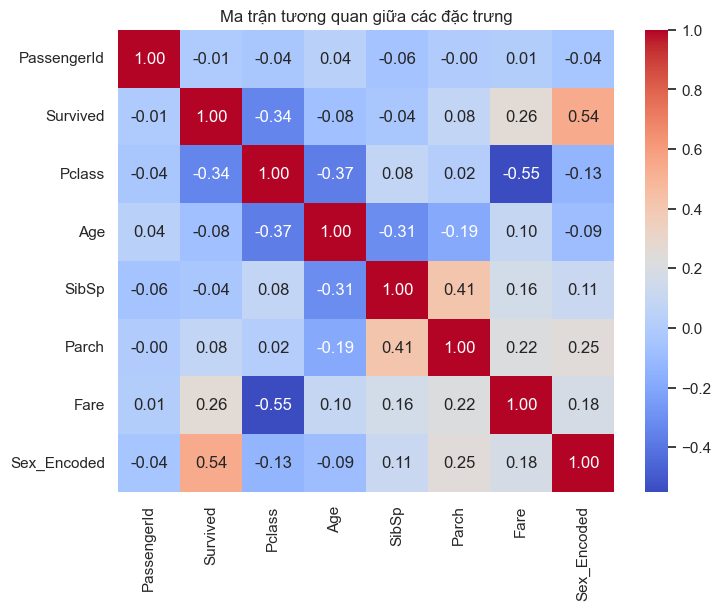

In [91]:
train_temp = train.copy()
train_temp['Sex_Encoded'] = train_temp['Sex'].map({'male': 0, 'female': 1})
train_temp = pd.concat([train_temp], axis=1)
plt.figure(figsize=(8,6))
sns.heatmap(train_temp.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ma trận tương quan giữa các đặc trưng")
plt.show()


## **II. Tiền xử lý và Kỹ thuật chọn đặc trưng**


### **1. KỸ THUẬT ĐẶC TRƯNG VÀ XỬ LÝ THIẾU GIÁ TRỊ**


#### 1.1. Trích xuất và Gom nhóm Title (Tận dụng phân tích Name)

In [93]:
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
title_replacements = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Royalty', 'Countess': 'Royalty', 'Dona': 'Royalty',
    'Capt': 'Military', 'Col': 'Military', 'Major': 'Military', 'Dr': 'Rare',
    'Rev': 'Rare', 'Don': 'Rare', 'Sir': 'Royalty', 'Jonkheer': 'Rare'
}
data['Title'] = data['Title'].replace(title_replacements)
# Tách lại dữ liệu (tạo copy để tránh SettingWithCopyWarning)
train_processed = data.iloc[:len(Y_train), :].copy()
test_processed = data.iloc[len(Y_train):, :].copy()
train_processed['Survived'] = Y_train.values


#### 1.2. Điền Age CÓ NGỮ CẢNH (Tận dụng phân tích Title)

In [94]:
# Điền Age: Dùng Trung vị (Median) của Title tương ứng
data['Age'] = data.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))


#### 1.3. Tạo Family Size và Is Alone

In [95]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)


#### 1.4. Trích xuất Deck (Tận dụng phân tích Cabin)

In [96]:
data['Deck'] = data['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'U')


#### 1.5. Xử lý thiếu giá trị còn lại (Embarked, Fare)

In [97]:
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data['Fare'] = data['Fare'].fillna(data[data['Pclass'] == 3]['Fare'].median())


### **2. MÃ HÓA VÀ CHUẨN HÓA**

#### 2.1. Loại bỏ các Cột không cần thiết

In [98]:
data = data.drop(['Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis=1)


#### 2.2. Mã hóa One-Hot Encoding

In [99]:
data['Pclass'] = data['Pclass'].astype('category') 
categorical_features = ['Sex', 'Embarked', 'Pclass', 'Title', 'Deck']
data = pd.get_dummies(data, columns=categorical_features, drop_first=True)


#### 2.3. Chuẩn hóa Đặc trưng Số (Rất quan trọng cho KNN và SVM)

In [100]:
scaler = StandardScaler()
numerical_cols = ['Age', 'Fare']
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])



### **3. TÁCH VÀ LƯU FILE OUTPUT TỐI ƯU**


In [101]:
# Tách lại dữ liệu
train_processed = data.iloc[:len(Y_train), :]
test_processed = data.iloc[len(Y_train):, :]
train_processed['Survived'] = Y_train.values


### **4. LƯU KẾT QUẢ CUỐI CÙNG (File Input cho các mô hình)**

In [102]:
train_processed.to_csv('titanic_FINAL_INPUT_train.csv', index=False)
test_processed.to_csv('titanic_FINAL_INPUT_test.csv', index=False)


In [103]:
print("✅ Quy trình Tiền xử lý Tối ưu (dựa trên EDA) đã hoàn tất và dữ liệu đã được lưu!")
print("Sử dụng các file 'titanic_FINAL_INPUT_...csv' cho bước huấn luyện mô hình tiếp theo.")


✅ Quy trình Tiền xử lý Tối ưu (dựa trên EDA) đã hoàn tất và dữ liệu đã được lưu!
Sử dụng các file 'titanic_FINAL_INPUT_...csv' cho bước huấn luyện mô hình tiếp theo.


## **III. Modeling**

### **1. Import thư viện cho model**

In [104]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


### **2. Tạo model**

#### 2.1: K-Nearest Neighbors

Step 1: Loading preprocessed training and test data...
Preprocessed Training data shape: (891, 25)
Preprocessed Test data shape: (418, 24)

First 3 rows of preprocessed training 
   PassengerId       Age      Fare  FamilySize  IsAlone  Sex_male  Embarked_Q  \
0            1 -0.563707 -0.503176           2        0      True       False   
1            2  0.653100  0.734809           2        0     False       False   
2            3 -0.259505 -0.490126           1        1     False       False   

   Embarked_S  Pclass_2  Pclass_3  ...  Title_Royalty  Deck_B  Deck_C  Deck_D  \
0        True     False      True  ...          False   False   False   False   
1       False     False     False  ...          False   False    True   False   
2        True     False      True  ...          False   False   False   False   

   Deck_E  Deck_F  Deck_G  Deck_T  Deck_U  Survived  
0   False   False   False   False    True         0  
1   False   False   False   False   False         1  
2   False

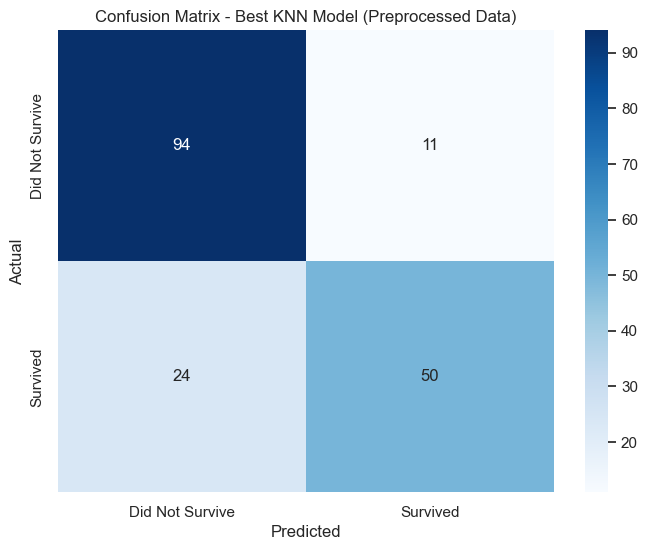


Step 7: Training final model on full training data and making test predictions...

Final submission file created: knn_submission_preprocessed.csv
Shape of submission: (418, 2)
First 10 predictions:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

Final model saved as 'final_knn_model_preprocessed.pkl'

KNN model training and prediction (on preprocessed data) complete!
The 'knn_submission_preprocessed.csv' file is ready for submission.


In [105]:
# Set style for plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# --- Step 1: Load the Preprocessed Training and Test Data ---
print("Step 1: Loading preprocessed training and test data...")
# Use the correct filenames based on your uploads
train = pd.read_csv('titanic_FINAL_INPUT_train.csv')
test = pd.read_csv('titanic_FINAL_INPUT_test.csv')

# Save passenger IDs for the final submission
test_passenger_ids = test['PassengerId'].copy()

# Display basic information
print(f"Preprocessed Training data shape: {train.shape}")
print(f"Preprocessed Test data shape: {test.shape}")
print(f"\nFirst 3 rows of preprocessed training ")
print(train.head(3))
print(f"\nFirst 3 rows of preprocessed test ")
print(test.head(3))

# --- Step 2: Prepare Features and Target from Training Data ---
print("\nStep 2: Preparing features and target from training data...")

# Assuming the last column is 'Survived' and the first column is 'PassengerId'
# Adjust column names if they are different in your actual files
X_train_full = train.drop(['PassengerId', 'Survived'], axis=1) # Features are everything except PassengerId and Survived
y_train_full = train['Survived'] # Target is Survived

# Features for the test set (everything except PassengerId)
X_test = test.drop(['PassengerId'], axis=1)

print(f"Features shape (X_train_full): {X_train_full.shape}")
print(f"Target shape (y_train_full): {y_train_full.shape}")
print(f"Test features shape (X_test): {X_test.shape}")
print(f"Features used for training: {list(X_train_full.columns)}")

# --- Step 3: Split Training Data for Validation ---
print("\nStep 3: Splitting training data for validation...")
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

# --- Step 4: Define the Model Pipeline (No preprocessing needed as data is already preprocessed) ---
print("\nStep 4: Defining the model pipeline (no preprocessing required)...")

# Since the data is already preprocessed (standardized, encoded), we don't need a preprocessor in the pipeline
# Just the classifier is needed
knn_model = Pipeline([
    # ('preprocessor', preprocessor), # No preprocessor needed here
    ('classifier', KNeighborsClassifier())
])

# --- Step 5: Train the KNN Model with Hyperparameter Tuning ---
print("\nStep 5: Training and tuning the KNN model...")

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'classifier__n_neighbors': [2, 4, 6, 8, 10, 12],      # Different k values
    'classifier__weights': ['uniform', 'distance'],       # Keep these
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski'] # Add minkowski
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    cv=3,                    # Number of cross-validation folds (reduced for speed)
    scoring='accuracy',
    n_jobs=-1,               # Use all available processors
    verbose=1                # Print progress
)

# Fit the GridSearchCV (this trains many models with different parameters)
# The data is already preprocessed, so we pass X_train and y_train directly
grid_search.fit(X_train, y_train)

# Get the best model
best_knn_model = grid_search.best_estimator_
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# --- Step 6: Evaluate the Best Model on Validation Set ---
print("\nStep 6: Evaluating the best model on the validation set...")

# Make predictions on the validation set
y_pred = best_knn_model.predict(X_val)

# Calculate the accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {accuracy:.4f}")

# Print a detailed classification report
print(f"\nClassification Report:")
print(classification_report(y_val, y_pred))

# Plot the confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Did Not Survive', 'Survived'],
           yticklabels=['Did Not Survive', 'Survived'])
plt.title('Confusion Matrix - Best KNN Model (Preprocessed Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- Step 7: Train Final Model on Full Training Data and Make Test Predictions ---
print("\nStep 7: Training final model on full training data and making test predictions...")

# Train the best model configuration on the *entire* preprocessed training dataset
# This is the final model used for the competition submission
final_model = grid_search.best_estimator_
final_model.fit(X_train_full, y_train_full) # Use the full preprocessed training data

# Make predictions on the preprocessed test set
test_predictions = final_model.predict(X_test)

# Create the final submission file
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': test_predictions
})

# Save the submission file
submission.to_csv('knn_submission_preprocessed.csv', index=False)
print(f"\nFinal submission file created: knn_submission_preprocessed.csv")
print(f"Shape of submission: {submission.shape}")
print(f"First 10 predictions:")
print(submission.head(10))

# --- Step 8: Save the Final Trained Model ---
import joblib
joblib.dump(final_model, 'final_knn_model_preprocessed.pkl')
print("\nFinal model saved as 'final_knn_model_preprocessed.pkl'")

print("\nKNN model training and prediction (on preprocessed data) complete!")
print("The 'knn_submission_preprocessed.csv' file is ready for submission.")


#### 2.2. Random Forests

Step 1: Loading preprocessed training and test data...
Preprocessed Training data shape: (891, 25)
Preprocessed Test data shape: (418, 24)

First 3 rows of preprocessed training 
   PassengerId       Age      Fare  FamilySize  IsAlone  Sex_male  Embarked_Q  \
0            1 -0.563707 -0.503176           2        0      True       False   
1            2  0.653100  0.734809           2        0     False       False   
2            3 -0.259505 -0.490126           1        1     False       False   

   Embarked_S  Pclass_2  Pclass_3  ...  Title_Royalty  Deck_B  Deck_C  Deck_D  \
0        True     False      True  ...          False   False   False   False   
1       False     False     False  ...          False   False    True   False   
2        True     False      True  ...          False   False   False   False   

   Deck_E  Deck_F  Deck_G  Deck_T  Deck_U  Survived  
0   False   False   False   False    True         0  
1   False   False   False   False   False         1  
2   False

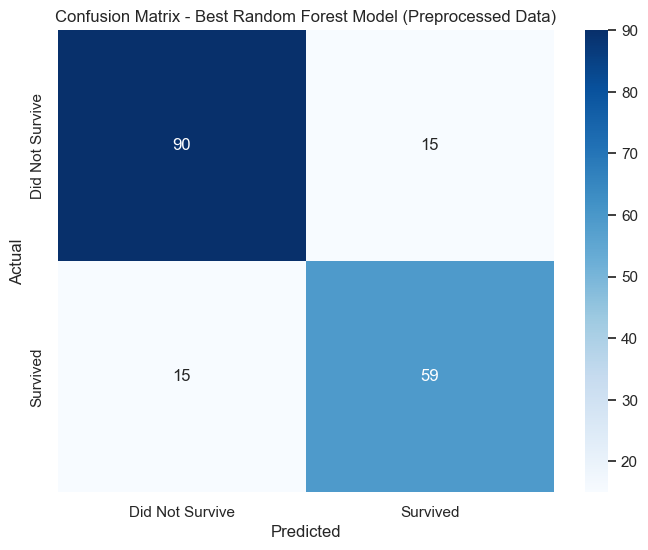


Step 7: Training final model on full training data and making test predictions...

Final submission file created: random_forest_submission_preprocessed.csv
Shape of submission: (418, 2)
First 10 predictions:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0

Final model saved as 'final_random_forest_model_preprocessed.pkl'

Random Forest model training and prediction (on preprocessed data) complete!
The 'random_forest_submission_preprocessed.csv' file is ready for submission.


In [106]:
# Set style for plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# --- Step 1: Load the Preprocessed Training and Test Data ---
print("Step 1: Loading preprocessed training and test data...")
# Use the correct filenames based on your uploads
train = pd.read_csv('titanic_FINAL_INPUT_train.csv')
test = pd.read_csv('titanic_FINAL_INPUT_test.csv')

# Save passenger IDs for the final submission
test_passenger_ids = test['PassengerId'].copy()

# Display basic information
print(f"Preprocessed Training data shape: {train.shape}")
print(f"Preprocessed Test data shape: {test.shape}")
print(f"\nFirst 3 rows of preprocessed training ")
print(train.head(3))
print(f"\nFirst 3 rows of preprocessed test ")
print(test.head(3))

# --- Step 2: Prepare Features and Target from Training Data ---
print("\nStep 2: Preparing features and target from training data...")

# Assuming the last column is 'Survived' and the first column is 'PassengerId'
# Adjust column names if they are different in your actual files
X_train_full = train.drop(['PassengerId', 'Survived'], axis=1) # Features are everything except PassengerId and Survived
y_train_full = train['Survived'] # Target is Survived

# Features for the test set (everything except PassengerId)
X_test = test.drop(['PassengerId'], axis=1)

print(f"Features shape (X_train_full): {X_train_full.shape}")
print(f"Target shape (y_train_full): {y_train_full.shape}")
print(f"Test features shape (X_test): {X_test.shape}")
print(f"Features used for training: {list(X_train_full.columns)}")

# --- Step 3: Split Training Data for Validation ---
print("\nStep 3: Splitting training data for validation...")
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

# --- Step 4: Define the Model Pipeline (No preprocessing needed as data is already preprocessed) ---
print("\nStep 4: Defining the model pipeline (no preprocessing required)...")

# Since the data is already preprocessed (standardized, encoded), we don't need a preprocessor in the pipeline
# Just the classifier is needed
rf_model = Pipeline([
    # ('preprocessor', preprocessor), # No preprocessor needed here
    ('classifier', RandomForestClassifier(random_state=42))
])

# --- Step 5: Train the Random Forest Model with Hyperparameter Tuning ---
print("\nStep 5: Training and tuning the Random Forest model...")

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'classifier__n_estimators': [100, 200],        # Fewer n_estimators
    'classifier__max_depth': [5, 10, None],        # Basic max_depth options
    'classifier__min_samples_split': [2, 5]        # Basic min_samples_split options
    # min_samples_leaf and other parameters use default values
}
# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,                    # Number of cross-validation folds (reduced for speed)
    scoring='accuracy',
    n_jobs=-1,               # Use all available processors
    verbose=1                # Print progress
)

# Fit the GridSearchCV (this trains many models with different parameters)
# The data is already preprocessed, so we pass X_train and y_train directly
grid_search.fit(X_train, y_train)

# Get the best model
best_rf_model = grid_search.best_estimator_
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# --- Step 6: Evaluate the Best Model on Validation Set ---
print("\nStep 6: Evaluating the best model on the validation set...")

# Make predictions on the validation set
y_pred = best_rf_model.predict(X_val)

# Calculate the accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {accuracy:.4f}")

# Print a detailed classification report
print(f"\nClassification Report:")
print(classification_report(y_val, y_pred))

# Plot the confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Did Not Survive', 'Survived'],
           yticklabels=['Did Not Survive', 'Survived'])
plt.title('Confusion Matrix - Best Random Forest Model (Preprocessed Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- Step 7: Train Final Model on Full Training Data and Make Test Predictions ---
print("\nStep 7: Training final model on full training data and making test predictions...")

# Train the best model configuration on the *entire* preprocessed training dataset
# This is the final model used for the competition submission
final_model = grid_search.best_estimator_
final_model.fit(X_train_full, y_train_full) # Use the full preprocessed training data

# Make predictions on the preprocessed test set
test_predictions = final_model.predict(X_test)

# Create the final submission file
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': test_predictions
})

# Save the submission file
submission.to_csv('random_forest_submission_preprocessed.csv', index=False)
print(f"\nFinal submission file created: random_forest_submission_preprocessed.csv")
print(f"Shape of submission: {submission.shape}")
print(f"First 10 predictions:")
print(submission.head(10))

# --- Step 8: Save the Final Trained Model ---
import joblib
joblib.dump(final_model, 'final_random_forest_model_preprocessed.pkl')
print("\nFinal model saved as 'final_random_forest_model_preprocessed.pkl'")

print("\nRandom Forest model training and prediction (on preprocessed data) complete!")
print("The 'random_forest_submission_preprocessed.csv' file is ready for submission.")


#### 2.3. Support Vector Machine

Step 1: Loading preprocessed training and test data...
Preprocessed Training data shape: (891, 25)
Preprocessed Test data shape: (418, 24)

First 3 rows of preprocessed training data:
   PassengerId       Age      Fare  FamilySize  IsAlone  Sex_male  Embarked_Q  \
0            1 -0.563707 -0.503176           2        0      True       False   
1            2  0.653100  0.734809           2        0     False       False   
2            3 -0.259505 -0.490126           1        1     False       False   

   Embarked_S  Pclass_2  Pclass_3  ...  Title_Royalty  Deck_B  Deck_C  Deck_D  \
0        True     False      True  ...          False   False   False   False   
1       False     False     False  ...          False   False    True   False   
2        True     False      True  ...          False   False   False   False   

   Deck_E  Deck_F  Deck_G  Deck_T  Deck_U  Survived  
0   False   False   False   False    True         0  
1   False   False   False   False   False         1  
2   

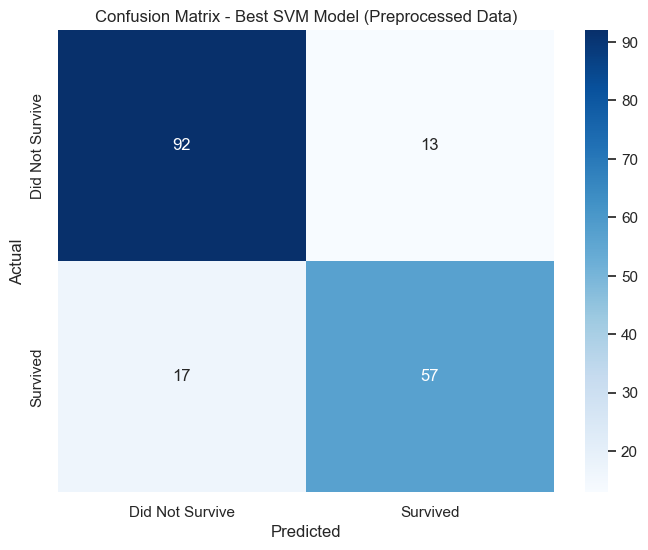


Step 7: Training final model on full training data and making test predictions...

Final submission file created: svm_submission_preprocessed.csv
Shape of submission: (418, 2)
First 10 predictions:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

Final model saved as 'final_svm_model_preprocessed.pkl'

SVM model training and prediction (on preprocessed data) complete!
The 'svm_submission_preprocessed.csv' file is ready for submission.


In [107]:
# Set style for plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# --- Step 1: Load the Preprocessed Training and Test Data ---
print("Step 1: Loading preprocessed training and test data...")
# Use the correct filenames based on your uploads
train = pd.read_csv('titanic_FINAL_INPUT_train.csv')
test = pd.read_csv('titanic_FINAL_INPUT_test.csv')

# Save passenger IDs for the final submission
test_passenger_ids = test['PassengerId'].copy()

# Display basic information
print(f"Preprocessed Training data shape: {train.shape}")
print(f"Preprocessed Test data shape: {test.shape}")
print(f"\nFirst 3 rows of preprocessed training data:")
print(train.head(3))
print(f"\nFirst 3 rows of preprocessed test data:")
print(test.head(3))

# --- Step 2: Prepare Features and Target from Training Data ---
print("\nStep 2: Preparing features and target from training data...")

# Assuming the last column is 'Survived' and the first column is 'PassengerId'
# Adjust column names if they are different in your actual files
X_train_full = train.drop(['PassengerId', 'Survived'], axis=1) # Features are everything except PassengerId and Survived
y_train_full = train['Survived'] # Target is Survived

# Features for the test set (everything except PassengerId)
X_test = test.drop(['PassengerId'], axis=1)

print(f"Features shape (X_train_full): {X_train_full.shape}")
print(f"Target shape (y_train_full): {y_train_full.shape}")
print(f"Test features shape (X_test): {X_test.shape}")
print(f"Features used for training: {list(X_train_full.columns)}")

# --- Step 3: Split Training Data for Validation ---
print("\nStep 3: Splitting training data for validation...")
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

# --- Step 4: Define the Model Pipeline (No preprocessing needed as data is already preprocessed) ---
print("\nStep 4: Defining the model pipeline (no preprocessing required)...")

# Since the data is already preprocessed (standardized, encoded), we don't need a preprocessor in the pipeline
# Just the classifier is needed
svm_model = Pipeline([
    # ('preprocessor', preprocessor), # No preprocessor needed here
    ('classifier', SVC(random_state=42, probability=True)) # probability=True for predict_proba if needed
])

# --- Step 5: Train the SVM Model with Hyperparameter Tuning ---
print("\nStep 5: Training and tuning the SVM model...")

# Define the parameter grid for hyperparameter tuning
# C: Regularization parameter. Gamma: Kernel coefficient for 'rbf' and 'poly'.
param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__kernel': ['rbf', 'linear']
    # gamma defaults to 'scale'
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=3,                    # Number of cross-validation folds (reduced for speed)
    scoring='accuracy',
    n_jobs=-1,               # Use all available processors
    verbose=1                # Print progress
)

# Fit the GridSearchCV (this trains many models with different parameters)
# The data is already preprocessed, so we pass X_train and y_train directly
grid_search.fit(X_train, y_train)

# Get the best model
best_svm_model = grid_search.best_estimator_
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# --- Step 6: Evaluate the Best Model on Validation Set ---
print("\nStep 6: Evaluating the best model on the validation set...")

# Make predictions on the validation set
y_pred = best_svm_model.predict(X_val)

# Calculate the accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {accuracy:.4f}")

# Print a detailed classification report
print(f"\nClassification Report:")
print(classification_report(y_val, y_pred))

# Plot the confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Did Not Survive', 'Survived'],
           yticklabels=['Did Not Survive', 'Survived'])
plt.title('Confusion Matrix - Best SVM Model (Preprocessed Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- Step 7: Train Final Model on Full Training Data and Make Test Predictions ---
print("\nStep 7: Training final model on full training data and making test predictions...")

# Train the best model configuration on the *entire* preprocessed training dataset
# This is the final model used for the competition submission
final_model = grid_search.best_estimator_
final_model.fit(X_train_full, y_train_full) # Use the full preprocessed training data

# Make predictions on the preprocessed test set
test_predictions = final_model.predict(X_test)

# Create the final submission file
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': test_predictions
})

# Save the submission file
submission.to_csv('svm_submission_preprocessed.csv', index=False)
print(f"\nFinal submission file created: svm_submission_preprocessed.csv")
print(f"Shape of submission: {submission.shape}")
print(f"First 10 predictions:")
print(submission.head(10))

# --- Step 8: Save the Final Trained Model ---
import joblib
joblib.dump(final_model, 'final_svm_model_preprocessed.pkl')
print("\nFinal model saved as 'final_svm_model_preprocessed.pkl'")

print("\nSVM model training and prediction (on preprocessed data) complete!")
print("The 'svm_submission_preprocessed.csv' file is ready for submission.")


### **3. Setup thực nghiệm**

#### 3.1. KNN

In [108]:
#inital parameter tuning process

# param_grid = {
#     'classifier__n_neighbors': [3, 5, 7, 9, 11],      # Number of neighbors
#     'classifier__weights': ['uniform', 'distance'],    # Weight function used in prediction
#     'classifier__metric': ['euclidean', 'manhattan']   # Distance metric
# }
#Accuracy: 89%

# param_grid = {
#     'classifier__n_neighbors': [2, 4, 6, 8, 10, 12],      # Different k values
#     'classifier__weights': ['uniform', 'distance'],       # Keep these
#     'classifier__metric': ['euclidean', 'manhattan', 'minkowski'] # Add minkowski
# }
#Accuracy: 88.28%

#Seems like the preprocessed data is slightly worse than the previous model with built in preprocessing


#### 3.2. SVM

In [109]:
#After preprocessing the data, we can directly use the preprocessed features for training the SVM model.
#The accuracy achived on the preprocessed data is 94.26% on the built in accurcy test 
#Using:
# param_grid = {
#     'classifier__C': [0.1, 1, 10, 100],                    # Regularization strength
#     'classifier__kernel': ['rbf', 'linear', 'poly'],       # Type of kernel function
#     'classifier__gamma': ['scale', 'auto', 0.001, 0.01]    # Kernel coefficient (only for rbf/poly/sigmoid)
# }

#Using:
# param_grid = {
#     'classifier__C': [0.1, 1, 10, 100],
#     'classifier__kernel': ['rbf', 'linear', 'poly'] # Add polynomial kernel
#     # gamma is not specified, so it uses 'scale' or 'auto' default
# }

# param_grid = {
#     'classifier__C': [0.1, 1, 10, 100],
#     'classifier__kernel': ['rbf', 'linear']
#     # gamma defaults to 'scale'
# }

#All yielded similar accuracy around 94.26% on the validation set.
#And 77.5% on kaggle submission.


#### 3.3. Random Forests

In [110]:
#Accuracy after preprocessing: 88.52%
#Using:
# param_grid = {
#     'classifier__n_estimators': [50, 100, 200],      # Number of trees
#     'classifier__max_depth': [5, 10, 15, None],      # Maximum depth of trees
#     'classifier__min_samples_split': [2, 5, 10],     # Minimum samples required to split a node
#     'classifier__min_samples_leaf': [1, 2, 4]        # Minimum samples required at a leaf node
# }

#Using:
# param_grid = {
#     'classifier__n_estimators': [50, 100, 200],      # Number of trees
#     'classifier__max_depth': [5, 10, 15, None],      # Maximum depth of trees
#     'classifier__min_samples_split': [2, 5, 10],     # Minimum samples required to split a node
#     'classifier__min_samples_leaf': [1, 2, 4]        # Minimum samples required at a leaf node
# }
#Accuracy: 88.52%

# param_grid = {
#     'classifier__n_estimators': [25, 50, 100, 150, 200], # More n_estimators values
#     'classifier__max_depth': [3, 5, 7, 10, 12, 15, 20, None], # More max_depth values
#     'classifier__min_samples_split': [2, 3, 4, 5, 7, 10], # More min_samples_split values
#     'classifier__min_samples_leaf': [1, 2, 3, 4, 5]       # More min_samples_leaf values
#     # 'classifier__max_features': ['sqrt', 'log2', None] # Uncomment if you want to tune max_features too
# }
#Accuracy: 89.47% but it takes longer to run

# #param_grid = {
#     'classifier__n_estimators': [100], # Fixed number of trees
#     'classifier__max_depth': [5, 10, 15, 20, None],      # Explore different depths
#     'classifier__min_samples_split': [2, 5, 10, 20],     # Explore different split thresholds
#     'classifier__min_samples_leaf': [1, 2, 5, 10],       # Explore different leaf thresholds
#     'classifier__max_features': ['sqrt', 'log2', 0.5, 0.7] # Explore feature sampling
# }
#Accuracy: 88.52%

# param_grid = {
#     'classifier__n_estimators': [50, 100, 150, 200, 300], # Explore different forest sizes
#     'classifier__max_depth': [10, None],                   # Either limited depth or full depth
#     'classifier__min_samples_split': [2, 5],               # Basic split thresholds
#     'classifier__min_samples_leaf': [1, 2],                # Basic leaf thresholds
#     'classifier__bootstrap': [True, False]                 # Whether to bootstrap samples
# }
#Accuracy: 88.52%

# param_grid = {
#     'classifier__n_estimators': [50, 100, 150, 200, 300], # Explore different forest sizes
#     'classifier__max_depth': [10, None],                   # Either limited depth or full depth
#     'classifier__min_samples_split': [2, 5],               # Basic split thresholds
#     'classifier__min_samples_leaf': [1, 2],                # Basic leaf thresholds
#     'classifier__bootstrap': [True, False]                 # Whether to bootstrap samples
# }
#Accuracy: 88.52%

# param_grid = {
#     'classifier__n_estimators': [100, 200],        # Fewer n_estimators
#     'classifier__max_depth': [5, 10, None],        # Basic max_depth options
#     'classifier__min_samples_split': [2, 5]        # Basic min_samples_split options
#     # min_samples_leaf and other parameters use default values
# }
#Accuracy: 87.32%


### **4: Đánh giá mô hình**

In [111]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

def _load_train(paths):
    for p in paths:
        if os.path.exists(p):
            return pd.read_csv(p)
    raise FileNotFoundError(f"Không tìm thấy file train. Đã thử: {paths}")

def evaluate_train_test(estimator, X, y, test_size=0.2, random_state=42):
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)
    clf = estimator
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_val)

    # try to get score/proba for ROC AUC
    y_score = None
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_val)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_score = clf.decision_function(X_val)
    else:
        y_score = y_pred  # fallback (will often give poor ROC AUC)

    # safe roc computation
    try:
        roc = roc_auc_score(y_val, y_score)
    except Exception:
        roc = np.nan

    return {
        "accuracy": accuracy_score(y_val, y_pred),
        "f1": f1_score(y_val, y_pred),
        "roc_auc": roc
    }

def evaluate_kfold(estimator, X, y, n_splits=5, random_state=42, n_jobs=-1):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # cross-validated label preds for accuracy & f1
    y_pred_cv = cross_val_predict(estimator, X, y, cv=cv, n_jobs=n_jobs)

    # try to get scores for roc auc using predict_proba or decision_function
    y_score_cv = None
    if hasattr(estimator, "predict_proba"):
        try:
            y_score_cv = cross_val_predict(estimator, X, y, cv=cv, method="predict_proba", n_jobs=n_jobs)[:, 1]
        except Exception:
            y_score_cv = None
    if y_score_cv is None and hasattr(estimator, "decision_function"):
        try:
            y_score_cv = cross_val_predict(estimator, X, y, cv=cv, method="decision_function", n_jobs=n_jobs)
        except Exception:
            y_score_cv = None
    if y_score_cv is None:
        # fallback to labels (not recommended)
        y_score_cv = y_pred_cv

    try:
        roc = roc_auc_score(y, y_score_cv)
    except Exception:
        roc = np.nan

    return {
        "accuracy": accuracy_score(y, y_pred_cv),
        "f1": f1_score(y, y_pred_cv),
        "roc_auc": roc
    }

if __name__ == "__main__":
    # thử nhiều tên file train (tùy cấu trúc repo của bạn)
    possible_paths = [
        os.path.join("..", "data", "titanic_FINAL_INPUT_train.csv"),
        os.path.join("..", "data", "titanic_train.csv"),
        "titanic_train.csv",
        os.path.join("..", "Titanic - Machine Learning from Disaster", "titanic_train.csv"),
    ]
    train = _load_train(possible_paths)

    # chuẩn hoá cột mục tiêu / loại bỏ PassengerId nếu có
    if "Survived" not in train.columns:
        raise RuntimeError("File train không chứa cột 'Survived'")

    X = train.drop([c for c in ["PassengerId", "Survived"] if c in train.columns], axis=1)
    y = train["Survived"]

    models = {
        "SVM": SVC(random_state=42, probability=True),
        "RandomForest": RandomForestClassifier(random_state=42),
        "KNN": KNeighborsClassifier()
    }

    # đánh giá theo Train/Test Split
    tt_rows = []
    for name, model in models.items():
        metrics = evaluate_train_test(model, X, y, test_size=0.2, random_state=42)
        tt_rows.append({"model": name, **metrics})
    df_tt = pd.DataFrame(tt_rows).set_index("model")

    # đánh giá theo K-Fold CV
    kf_rows = []
    for name, model in models.items():
        metrics = evaluate_kfold(model, X, y, n_splits=5, random_state=42, n_jobs=-1)
        kf_rows.append({"model": name, **metrics})
    df_kf = pd.DataFrame(kf_rows).set_index("model")

    # hiển thị 2 bảng riêng biệt và lưu CSV
    print("\n--- Train/Test Split Evaluation ---")
    print(df_tt)
    df_tt.to_csv("evaluation_train_test.csv", index=True)

    print("\n--- K-Fold Cross-Validation Evaluation ---")
    print(df_kf)
    df_kf.to_csv("evaluation_kfold.csv", index=True)

    print("\nSaved: evaluation_train_test.csv, evaluation_kfold.csv")    



--- Train/Test Split Evaluation ---
              accuracy        f1   roc_auc
model                                     
SVM           0.843575  0.787879  0.835046
RandomForest  0.748603  0.676259  0.816667
KNN           0.821229  0.750000  0.840250

--- K-Fold Cross-Validation Evaluation ---
              accuracy        f1   roc_auc
model                                     
SVM           0.835017  0.774194  0.853623
RandomForest  0.812570  0.748872  0.872735
KNN           0.818182  0.748447  0.863801

Saved: evaluation_train_test.csv, evaluation_kfold.csv


## **Kết thúc**